In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
nyugalmi_allapot = np.loadtxt("./adatok/nyugalmi_allapot.dat")

In [3]:
e_x = np.average(nyugalmi_allapot[:,2])
de_x = np.var(nyugalmi_allapot[:,2])
e_y = np.average(nyugalmi_allapot[:,3])
de_y = np.var(nyugalmi_allapot[:,3])
e_z = np.average(nyugalmi_allapot[:,4])
de_z = np.var(nyugalmi_allapot[:,4])
e_0 = np.array([e_x, e_y, e_z])
de_0 = np.array([de_x, de_y, de_z])
de_0 /= np.linalg.norm(e_0)
e_0 /= np.linalg.norm(e_0)

In [4]:
kiteritesek = [np.loadtxt("./adatok/kiterites_" + str(i) + ".dat") for i in range(1, 18)]

In [5]:
e_th = np.array([np.array([np.average(kiteritesek[i][:,j]) for j in range(2, 5)]) for i in range(len(kiteritesek))])
de_th = np.array([np.array([np.std(kiteritesek[i][:,j]) for j in range(2, 5)]) for i in range(len(kiteritesek))])
for i in range(len(e_th)):
    de_th[i] /= np.linalg.norm(e_th[i])
    e_th[i] /= np.linalg.norm(e_th[i])

In [6]:
def theta(e_0, e_th):
    #return np.dot(e_0, e_th)
    return np.arccos(np.dot(e_0, e_th))
def dtheta(e_0, de_0, e_th, de_th):
    cdth = 0
    for i in range(3):
        cdth += (de_th[i] / e_th[i] + de_0[i] / e_0[i]) * e_th[i] * e_0[i]
    return  1 / np.sqrt(1 - np.dot(e_0, e_th) ** 2) * cdth

In [7]:
szog = [theta(e_0, e_th[i]) for i in range(10)]
dszog = [dtheta(e_0, de_0, e_th[i], de_th[i]) for i in range(10)]
x = np.array([np.average(kiteritesek[i][:,1]) for i in range(10)])
dx = np.array([np.std(kiteritesek[i][:,1]) for i in range(10)])

In [8]:
def linearis(x, a, b):
    return a * x + b

In [9]:
szog_illesztes = curve_fit(linearis, x, szog, sigma=dszog)

In [10]:
def szog_ertek(x):
    return linearis(x, szog_illesztes[0][0], szog_illesztes[0][1])

In [11]:
print(szog_illesztes[0])
print(np.sqrt(np.diag(szog_illesztes[1])))

[ 0.00401298 -1.95742475]
[6.43455731e-05 4.64515771e-02]


In [12]:
def lenges(t, theta_0, theta_max, tau, T, phi):
    return theta_0 + theta_max * np.exp(-t / tau) * np.sin(2 * np.pi * t / T + phi)

In [13]:
lengesek = [np.loadtxt("./adatok/jo_lenges_" + str(i) + ".dat") for i in range(1, 12)]

In [14]:
for i in lengesek:
    i[:,0] -= i[:,0][0]

In [15]:
lenges_illesztes = [curve_fit(lenges, lengesek[i][:,0], szog_ertek(lengesek[i][:,1])) for i in range(11)]
for i in lenges_illesztes:
    if i[0][1] < 0:
        i[0][1] += np.pi

lenges_parameterek = []
lenges_hibak = []
for i in range(len(lenges_illesztes)):
    lenges_parameterek.append(lenges_illesztes[i][0])
    lenges_hibak.append(np.sqrt(np.diag(lenges_illesztes[i][1])))
lenges_parameterek = np.array(lenges_parameterek)
lenges_hibak = np.array(lenges_hibak)

C:\Users\kutykurutty\AppData\Local\Temp\ipykernel_3008\2792426459.py:2: RuntimeWarning: overflow encountered in exp
  return theta_0 + theta_max * np.exp(-t / tau) * np.sin(2 * np.pi * t / T + phi)


In [16]:
def lenges_ido(beta, theta):
    T_0, a = beta
    return T_0 * (1 + (theta ** 2) / a)

In [17]:
from scipy.odr import ODR, Model, Data, RealData

In [18]:
#lenges_ido_illesztes = curve_fit(lenges_ido, lenges_parameterek[:,3], lenges_parameterek[:,1], p0=[2, 16])
data = RealData(lenges_parameterek[:,1], lenges_parameterek[:,3], lenges_hibak[:,1], lenges_hibak[:,3])
model = Model(lenges_ido)

odr = ODR(data, model, beta0=[1.8, 16])
odr.set_job(fit_type=0)
output = odr.run()


In [19]:
#print(lenges_ido_illesztes[0])
#print(np.sqrt(np.diag(lenges_ido_illesztes[1])))
print(output.beta)

[ 1.76935048 15.4431949 ]


In [20]:
lenges_parameterek_sort = lenges_parameterek[lenges_parameterek[:,1].argsort()]


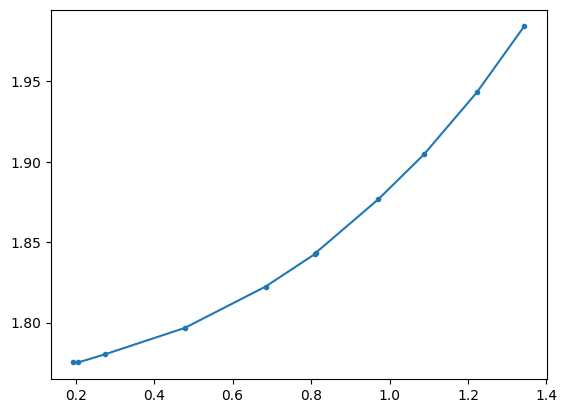

In [21]:
plt.plot(lenges_parameterek_sort[:,1], lenges_parameterek_sort[:,3], ".-")

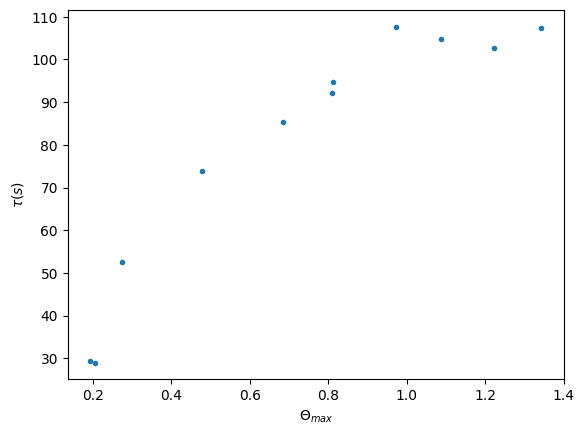

In [42]:
plt.plot(lenges_parameterek_sort[:,1], lenges_parameterek_sort[:,2], ".")
plt.xlabel("$\\Theta_{max}$")
plt.ylabel("$\\tau(s)$")
plt.show()

In [23]:
for i in range(10):
    print(x[i], end=" & ")
    print(dx[i], end=" & ")
    print("$\\begin{pmatrix} " + str(e_th[i][0]) + " \\\\ " + str(e_th[i][1]) + " \\\\ " + str(e_th[i][2]) + "\\end{pmatrix}$", end=" & ")
    print("$\\begin{pmatrix} " + str(de_th[i][0]) + " \\\\ " + str(de_th[i][1]) + " \\\\ " + str(de_th[i][2]) + "\\end{pmatrix}$", end=" ")
    print("\\\\")

558.0705009276438 & 1.030896510562913 & $\begin{pmatrix} 0.10356473229034938 \\ 0.28045265097445476 \\ 0.9542644585161019\end{pmatrix}$ & $\begin{pmatrix} 0.0031824634907438045 \\ 0.0032441900699871884 \\ 0.004491535881692812\end{pmatrix}$ \\
589.0514842300556 & 1.0127400996759084 & $\begin{pmatrix} 0.15432212327331055 \\ 0.37148580857352564 \\ 0.9155233346544975\end{pmatrix}$ & $\begin{pmatrix} 0.003818028239839808 \\ 0.0048068297644212055 \\ 0.004510043701877748\end{pmatrix}$ \\
639.9141929499073 & 1.0723212073234931 & $\begin{pmatrix} 0.23329156342493856 \\ 0.5132456743112023 \\ 0.8259261009530982\end{pmatrix}$ & $\begin{pmatrix} 0.0038825463333280272 \\ 0.00510379927824096 \\ 0.004665856052126526\end{pmatrix}$ \\
657.993829699712 & 1.0893651130098192 & $\begin{pmatrix} 0.26010776322584517 \\ 0.5577046035543902 \\ 0.7882318990524857\end{pmatrix}$ & $\begin{pmatrix} 0.0031150609882227673 \\ 0.00321135952249969 \\ 0.0046160108609061\end{pmatrix}$ \\
678.2339857651245 & 1.0420268982789

In [24]:
for i in range(10):
    print(x[i], end=" & ")
    print(dx[i], end=" & ")
    print(szog[i], end=" & ")
    print(dszog[i], end=" ")
    print("\\\\")

558.0705009276438 & 1.030896510562913 & 0.31753175217518875 & 0.014009724894295987 \\
589.0514842300556 & 1.0127400996759084 & 0.428770153546673 & 0.010519479836917128 \\
639.9141929499073 & 1.0723212073234931 & 0.6143716795691391 & 0.007855569711851093 \\
657.993829699712 & 1.0893651130098192 & 0.6785415476689789 & 0.007172610121812045 \\
678.2339857651245 & 1.04202689827896 & 0.751796963312822 & 0.00663817432998387 \\
686.4417259786477 & 1.055903187120231 & 0.7948519373074271 & 0.006363262646582382 \\
700.1382189239332 & 1.0640025685997982 & 0.8419074011718616 & 0.006088847231819175 \\
749.2351576994434 & 0.9764801443695382 & 1.0441217282070936 & 0.005243860457930683 \\
773.9387755102041 & 1.1211241971228147 & 1.1425306073524621 & 0.004922231614377152 \\
798.3961038961039 & 0.9202240371944543 & 1.262782031808849 & 0.004847801114242626 \\


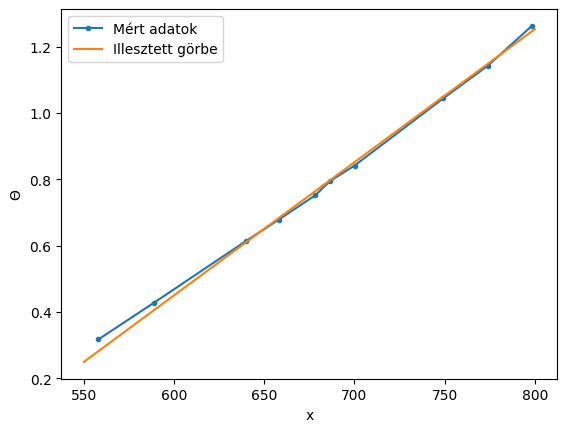

In [25]:
plt.plot(x, szog, ".-", label="Mért adatok")
x_lin = np.linspace(550, 800, 300)
plt.plot(x_lin, szog_ertek(x_lin), label="Illesztett görbe")
plt.xlabel("x")
plt.ylabel("$\\Theta$")
plt.legend()
plt.show()

In [26]:
for i in range(11):
    print(i + 1, end=". & ")
    print(lenges_parameterek[i][0], end=" & ")
    print(lenges_parameterek[i][1], end=" & ")
    print(lenges_parameterek[i][2], end=" & ")
    print(lenges_parameterek[i][3], end=" & ")
    print(lenges_parameterek[i][4], end=" ")
    print("\\\\")

1. & -0.04189469915634184 & 1.2231153837642714 & 102.65257068586374 & 1.943368045686938 & 1.280783610017449 \\
2. & -0.04292199405314681 & 1.0886557431966577 & 104.77733777260472 & 1.9048621945722173 & 1.314087492110795 \\
3. & -0.055783205501158784 & 0.47786035739025534 & 73.91897075321376 & 1.796694314920793 & 0.9245527878048351 \\
4. & -0.06172635223189695 & 0.2749803112475305 & 52.60934615203466 & 1.780326779016689 & 2.3195811450829016 \\
5. & -0.06216618136777824 & 0.20598643447796172 & 28.994146849057696 & 1.7752299495747246 & 1.2145290604906043 \\
6. & -0.04886994656626797 & 0.8127283215864024 & 94.816798924093 & 1.8435828903646496 & 1.6104020420956182 \\
7. & -0.04967735210907178 & 0.8097101778147222 & 92.04333654100743 & 1.8426445236379925 & 0.967271777155893 \\
8. & -0.05229750714635757 & 0.6839269546141286 & 85.3460771247053 & 1.8224214022476541 & 1.4119482030688906 \\
9. & -0.0412439100462724 & 1.342918512479917 & 107.34771137759364 & 1.9841842650140782 & 1.3601900485242537

In [27]:
for i in range(11):
    print(i + 1, end=". & ")
    print(lenges_hibak[i][0], end=" & ")
    print(lenges_hibak[i][1], end=" & ")
    print(lenges_hibak[i][2], end=" & ")
    print(lenges_hibak[i][3], end=" & ")
    print(lenges_hibak[i][4], end=" ")
    print("\\\\")

1. & 0.000596803587790407 & 0.0015998174294469757 & 3.957503224119437 & 0.0002596049571315041 & 0.0014586921788457088 \\
2. & 0.00045446226366668206 & 0.0012206276493332397 & 3.6447207308004668 & 0.0002173924765251218 & 0.001240454602398234 \\
3. & 0.00019593248431843283 & 0.0005211662632716872 & 1.8413864119971775 & 0.00020216743671874675 & 0.001250873808006427 \\
4. & 0.000197996739689166 & 0.000586313054693474 & 1.937216486373955 & 0.00035069072606355777 & 0.0019612776761982133 \\
5. & 0.0001968462791963176 & 0.0005435048592905484 & 0.7082931579463204 & 0.000492184483789853 & 0.0029829873822529197 \\
6. & 0.00029239194191411845 & 0.000808136670489517 & 2.7079610666653746 & 0.00018006129570475465 & 0.0010429923961044383 \\
7. & 0.0002803254782274279 & 0.0007432217391329447 & 2.3659159913308567 & 0.0001741626377629062 & 0.0010487752714067754 \\
8. & 0.00026796114576740974 & 0.0007278938542531688 & 2.4519260561949356 & 0.00019540098630425561 & 0.0011516399325977227 \\
9. & 0.0007337331

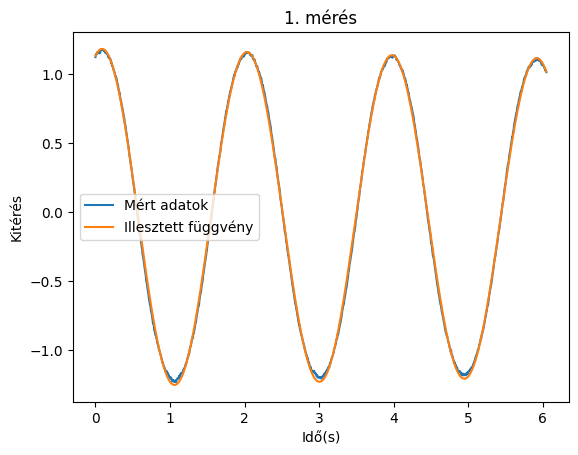

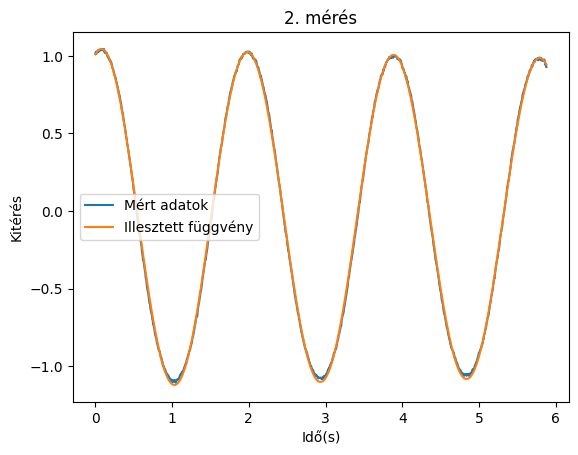

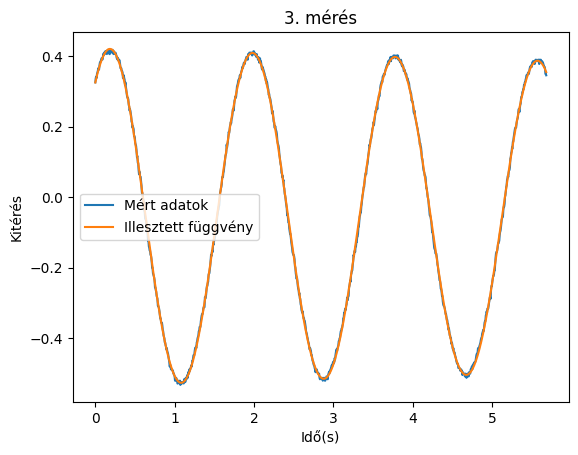

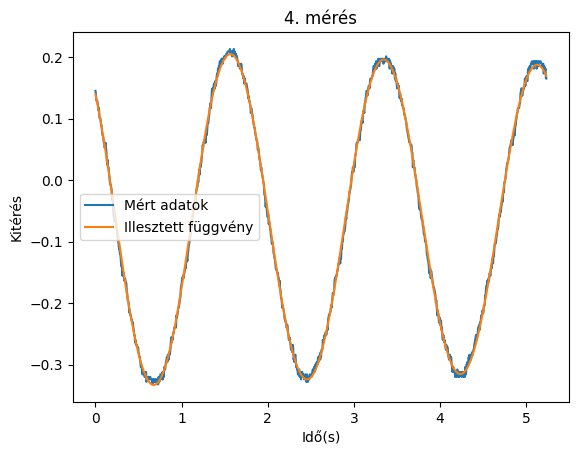

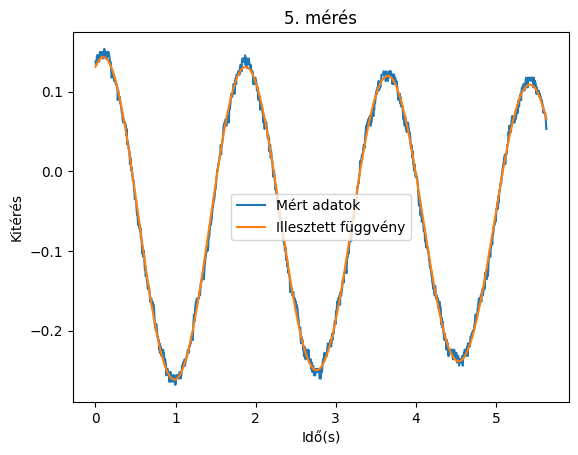

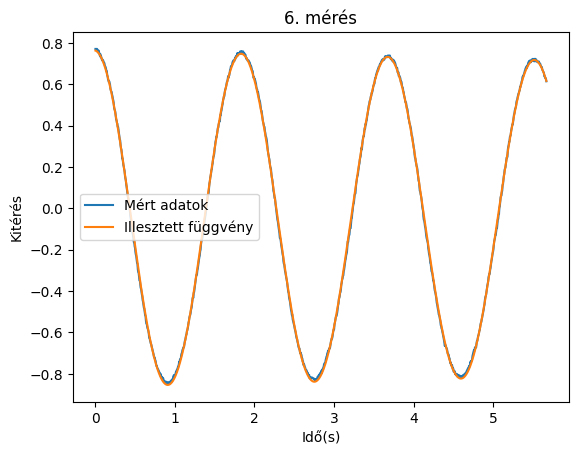

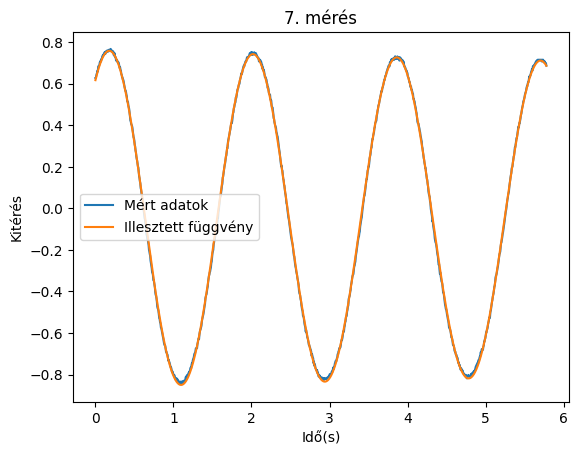

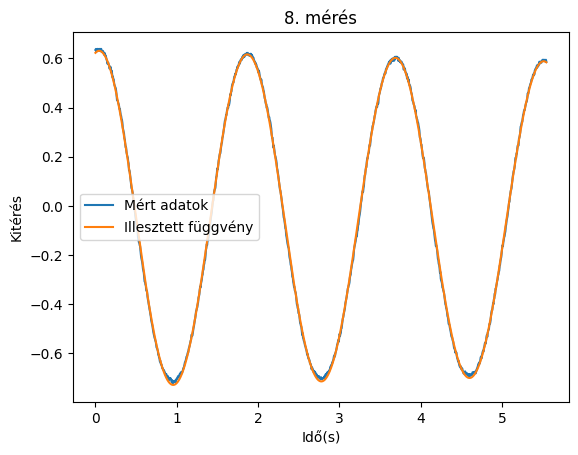

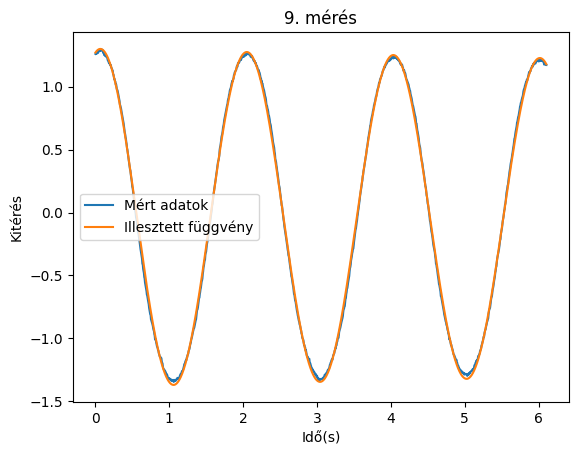

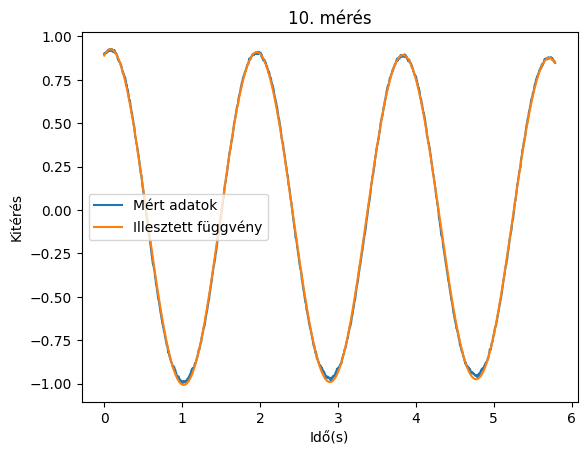

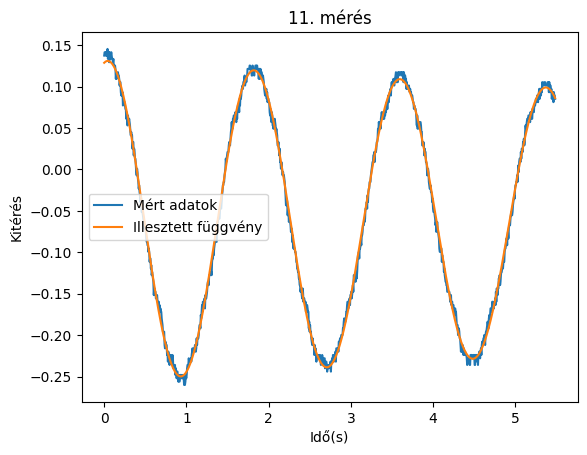

In [33]:
for i in range(11):
    plt.plot(lengesek[i][:,0], szog_ertek(lengesek[i][:,1]), label="Mért adatok")
    plt.plot(lengesek[i][:,0], lenges(lengesek[i][:,0], lenges_parameterek[i][0], lenges_parameterek[i][1], lenges_parameterek[i][2], lenges_parameterek[i][3], lenges_parameterek[i][4]), label="Illesztett függvény")
    plt.legend()
    plt.title(str(i + 1) +". mérés")
    plt.xlabel("Idő(s)")
    plt.ylabel("Kitérés")
    plt.show()

In [35]:
print(output.beta)
print(np.sqrt(np.diag(output.cov_beta)))

[ 1.76935048 15.4431949 ]
[0.000162  0.0329047]


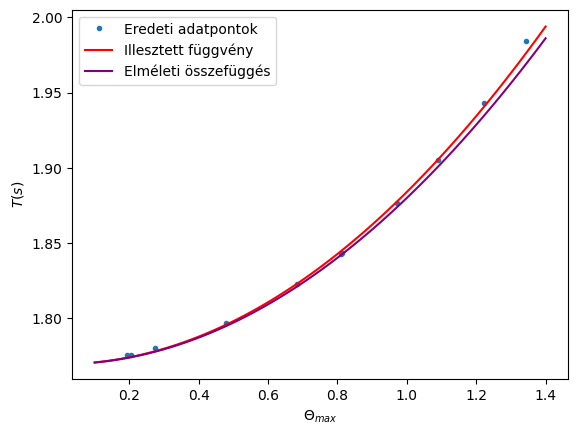

In [41]:
plt.plot(lenges_parameterek_sort[:,1], lenges_parameterek_sort[:,3], ".", label="Eredeti adatpontok")
th = np.linspace(0.1, 1.4, 100)
plt.plot(th, lenges_ido(output.beta, th), "r", label="Illesztett függvény")
plt.plot(th, lenges_ido([output.beta[0], 16], th), "purple", label="Elméleti összefüggés")
plt.xlabel("$\\Theta_{max}$")
plt.ylabel("$T(s)$")
plt.legend()
plt.show()